In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

# Step 1: Understand Your Data

### Load and preview the dataset.

In [2]:
US_Customer_Insights_Dataset = pd.read_csv("data\\us_consumer_profiles.csv")
US_Customer_Insights_Dataset

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103
...,...,...,...,...,...,...,...,...,...,...,...,...
10670,CUST10833,Steven Burns,Georgia,PhD,Female,60,No,1,8/24/23,2/29/24,341.28,518
10671,CUST10620,Jesse Pratt,Texas,Master,Male,64,No,0,4/13/23,12/31/24,468.04,212
10672,CUST10449,John Lloyd,Arizona,Master,Non-Binary,31,Yes,0,7/3/22,9/21/23,259.94,679
10673,CUST10020,Christopher Sparks,Florida,Bachelor,Female,31,No,0,9/19/23,12/29/23,494.17,580


In [3]:
US_Customer_Insights_Dataset.head(10)

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103
5,CUST10841,Stephen Cooke,Texas,PhD,Female,55,Yes,2,5/25/22,4/4/23,423.45,849
6,CUST10263,Rodney James,Ohio,High School,Non-Binary,61,No,0,11/20/23,3/26/24,402.96,492
7,CUST10117,Jeffrey Miles,Arizona,High School,Male,21,Yes,2,9/28/20,7/9/23,175.81,753
8,CUST10611,John Walsh,New York,Master,Male,74,No,2,5/15/21,7/30/22,320.48,1097
9,CUST10466,James Pope,New York,Master,Female,50,No,1,7/28/21,1/28/23,151.49,915


In [4]:
US_Customer_Insights_Dataset.tail(10)

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
10665,CUST10898,Heather Chavez,New York,Associate,Non-Binary,21,Yes,2,4/21/24,12/25/24,461.84,218
10666,CUST10564,Mary Shaw,Washington,Master,Female,41,No,0,7/13/24,11/11/24,483.33,262
10667,CUST10679,Ann Rose,Arizona,Associate,Male,54,Yes,0,10/4/22,7/17/25,839.65,14
10668,CUST10965,Kristin Dillon,Illinois,Master,Male,40,Yes,2,7/29/22,11/29/24,171.54,244
10669,CUST10596,Gary James,Georgia,Associate,Non-Binary,39,Yes,1,3/12/24,1/24/25,331.24,188
10670,CUST10833,Steven Burns,Georgia,PhD,Female,60,No,1,8/24/23,2/29/24,341.28,518
10671,CUST10620,Jesse Pratt,Texas,Master,Male,64,No,0,4/13/23,12/31/24,468.04,212
10672,CUST10449,John Lloyd,Arizona,Master,Non-Binary,31,Yes,0,7/3/22,9/21/23,259.94,679
10673,CUST10020,Christopher Sparks,Florida,Bachelor,Female,31,No,0,9/19/23,12/29/23,494.17,580
10674,CUST10267,Melissa Marshall,Arizona,Associate,Non-Binary,57,Yes,1,4/3/23,12/1/23,153.12,608


In [5]:
US_Customer_Insights_Dataset.shape

(10675, 12)

In [6]:
US_Customer_Insights_Dataset.info

<bound method DataFrame.info of       CustomerID                Name       State    Education      Gender  \
0      CUST10319         Scott Perez     Florida  High School  Non-Binary   
1      CUST10695     Jennifer Burton  Washington       Master        Male   
2      CUST10297     Michelle Rogers     Arizona       Master      Female   
3      CUST10103    Brooke Hendricks       Texas       Master        Male   
4      CUST10219         Karen Johns       Texas  High School      Female   
...          ...                 ...         ...          ...         ...   
10670  CUST10833        Steven Burns     Georgia          PhD      Female   
10671  CUST10620         Jesse Pratt       Texas       Master        Male   
10672  CUST10449          John Lloyd     Arizona       Master  Non-Binary   
10673  CUST10020  Christopher Sparks     Florida     Bachelor      Female   
10674  CUST10267    Melissa Marshall     Arizona    Associate  Non-Binary   

       Age Married  NumPets JoinDate Transa

### Check data types, unique values, and presence of nulls.

In [7]:
US_Customer_Insights_Dataset.columns

Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Age', 'Married',
       'NumPets', 'JoinDate', 'TransactionDate', 'MonthlySpend',
       'DaysSinceLastInteraction'],
      dtype='str')

In [8]:
US_Customer_Insights_Dataset.dtypes

CustomerID                      str
Name                            str
State                           str
Education                       str
Gender                          str
Age                           int64
Married                         str
NumPets                       int64
JoinDate                        str
TransactionDate                 str
MonthlySpend                float64
DaysSinceLastInteraction      int64
dtype: object

In [9]:
US_Customer_Insights_Dataset['JoinDate'] = pd.to_datetime(US_Customer_Insights_Dataset['JoinDate'])
US_Customer_Insights_Dataset.dtypes

C:\Users\Admin\AppData\Local\Temp\ipykernel_19348\4276795622.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  US_Customer_Insights_Dataset['JoinDate'] = pd.to_datetime(US_Customer_Insights_Dataset['JoinDate'])


CustomerID                             str
Name                                   str
State                                  str
Education                              str
Gender                                 str
Age                                  int64
Married                                str
NumPets                              int64
JoinDate                    datetime64[us]
TransactionDate                        str
MonthlySpend                       float64
DaysSinceLastInteraction             int64
dtype: object

In [10]:
US_Customer_Insights_Dataset['TransactionDate'] = pd.to_datetime(US_Customer_Insights_Dataset['TransactionDate'])
US_Customer_Insights_Dataset.dtypes

C:\Users\Admin\AppData\Local\Temp\ipykernel_19348\2238229443.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  US_Customer_Insights_Dataset['TransactionDate'] = pd.to_datetime(US_Customer_Insights_Dataset['TransactionDate'])


CustomerID                             str
Name                                   str
State                                  str
Education                              str
Gender                                 str
Age                                  int64
Married                                str
NumPets                              int64
JoinDate                    datetime64[us]
TransactionDate             datetime64[us]
MonthlySpend                       float64
DaysSinceLastInteraction             int64
dtype: object

In [11]:
US_Customer_Insights_Dataset

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,2021-09-19,2024-09-02,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,2024-04-05,2024-06-02,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,2024-07-24,2025-02-28,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,2023-08-12,2025-03-29,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,2021-12-06,2022-07-24,139.68,1103
...,...,...,...,...,...,...,...,...,...,...,...,...
10670,CUST10833,Steven Burns,Georgia,PhD,Female,60,No,1,2023-08-24,2024-02-29,341.28,518
10671,CUST10620,Jesse Pratt,Texas,Master,Male,64,No,0,2023-04-13,2024-12-31,468.04,212
10672,CUST10449,John Lloyd,Arizona,Master,Non-Binary,31,Yes,0,2022-07-03,2023-09-21,259.94,679
10673,CUST10020,Christopher Sparks,Florida,Bachelor,Female,31,No,0,2023-09-19,2023-12-29,494.17,580


In [12]:
US_Customer_Insights_Dataset.duplicated().sum()

np.int64(0)

In [13]:
US_Customer_Insights_Dataset.isnull().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

In [14]:
US_Customer_Insights_Dataset.isna().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

In [15]:
US_Customer_Insights_Dataset['CustomerID'].unique()

<ArrowStringArray>
['CUST10319', 'CUST10695', 'CUST10297', 'CUST10103', 'CUST10219', 'CUST10841',
 'CUST10263', 'CUST10117', 'CUST10611', 'CUST10466',
 ...
 'CUST10460', 'CUST10669', 'CUST10415', 'CUST10164', 'CUST10166', 'CUST10346',
 'CUST10201', 'CUST10271', 'CUST10312', 'CUST10268']
Length: 1000, dtype: str

In [16]:
US_Customer_Insights_Dataset['Name'].unique()

<ArrowStringArray>
[      'Scott Perez',   'Jennifer Burton',   'Michelle Rogers',
  'Brooke Hendricks',       'Karen Johns',     'Stephen Cooke',
      'Rodney James',     'Jeffrey Miles',        'John Walsh',
        'James Pope',
 ...
     'Vanessa Smith',         'Jeff Diaz',   'Vincent Spencer',
 'Patricia Jacobson',      'Ashley Burns',     'Maria Johnson',
      'Debra Chavez',   'Andrea Williams',       'Erin Norman',
 'Michelle Martinez']
Length: 990, dtype: str

In [17]:
US_Customer_Insights_Dataset['State'].unique()

<ArrowStringArray>
[   'Florida', 'Washington',    'Arizona',      'Texas',       'Ohio',
   'New York',   'Illinois',    'Georgia', 'California',   'Colorado']
Length: 10, dtype: str

In [18]:
US_Customer_Insights_Dataset['Education'].unique()

<ArrowStringArray>
['High School', 'Master', 'PhD', 'Bachelor', 'Associate']
Length: 5, dtype: str

In [19]:
US_Customer_Insights_Dataset['Gender'].unique()

<ArrowStringArray>
['Non-Binary', 'Male', 'Female']
Length: 3, dtype: str

In [20]:
US_Customer_Insights_Dataset['Age'].unique()

array([47, 72, 40, 27, 28, 55, 61, 21, 74, 50, 49, 30, 25, 78, 39, 26, 51,
       75, 38, 34, 68, 73, 37, 71, 43, 22, 79, 20, 52, 69, 18, 32, 58, 36,
       53, 46, 45, 44, 41, 29, 35, 56, 80, 62, 65, 54, 77, 67, 60, 70, 31,
       33, 64, 76, 59, 57, 23, 42, 63, 19, 66, 24, 48])

In [21]:
US_Customer_Insights_Dataset['Married'].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [22]:
US_Customer_Insights_Dataset['NumPets'].unique()

array([1, 0, 2, 3, 4])

In [23]:
US_Customer_Insights_Dataset['JoinDate'].unique()

<DatetimeArray>
['2021-09-19 00:00:00', '2024-04-05 00:00:00', '2024-07-24 00:00:00',
 '2023-08-12 00:00:00', '2021-12-06 00:00:00', '2022-05-25 00:00:00',
 '2023-11-20 00:00:00', '2020-09-28 00:00:00', '2021-05-15 00:00:00',
 '2021-07-28 00:00:00',
 ...
 '2022-08-04 00:00:00', '2023-02-07 00:00:00', '2024-02-13 00:00:00',
 '2021-03-18 00:00:00', '2021-10-22 00:00:00', '2024-04-04 00:00:00',
 '2023-07-24 00:00:00', '2023-10-24 00:00:00', '2022-08-26 00:00:00',
 '2023-08-07 00:00:00']
Length: 731, dtype: datetime64[us]

In [24]:
US_Customer_Insights_Dataset['TransactionDate'].unique()

<DatetimeArray>
['2024-09-02 00:00:00', '2024-06-02 00:00:00', '2025-02-28 00:00:00',
 '2025-03-29 00:00:00', '2022-07-24 00:00:00', '2023-04-04 00:00:00',
 '2024-03-26 00:00:00', '2023-07-09 00:00:00', '2022-07-30 00:00:00',
 '2023-01-28 00:00:00',
 ...
 '2021-01-29 00:00:00', '2021-05-11 00:00:00', '2022-05-30 00:00:00',
 '2020-11-29 00:00:00', '2021-10-14 00:00:00', '2021-03-09 00:00:00',
 '2021-09-17 00:00:00', '2022-01-11 00:00:00', '2022-04-07 00:00:00',
 '2021-06-04 00:00:00']
Length: 1605, dtype: datetime64[us]

In [25]:
US_Customer_Insights_Dataset['MonthlySpend'].unique()

array([1281.74,  429.46,  510.34, ...,  259.94,  494.17,  153.12],
      shape=(9843,))

In [26]:
US_Customer_Insights_Dataset['DaysSinceLastInteraction'].unique()

array([ 332,  424,  153, ..., 1297, 1211, 1518], shape=(1605,))

### Understand which variables are categorical and which are numerical.

**Categorical columns in the table are**
- CustomerID
- Name
- State
- Education
- Gender
- Married

**Numerical columns in the table are**
- Age
- NumPets
- MonthlySpend
- DaysSinceLastInteraction

# Step 2: Descriptive Statistics

### Business Purpose: Describe your customer base — how old are they, how much do theyspend, are they active?

In [27]:
US_Customer_Insights_Dataset['Age'].min()

np.int64(18)

In [28]:
US_Customer_Insights_Dataset['Age'].max()

np.int64(80)

In [29]:
US_Customer_Insights_Dataset['DaysSinceLastInteraction'].min()

np.int64(1)

In [30]:
US_Customer_Insights_Dataset['DaysSinceLastInteraction'].max()

np.int64(1791)

In [31]:
age_bins = [0, 25, 45, 65, 100]
age_labels = ['0-25', '25-45', '45-65', '65-100']
activity_threshold = 60

spending_and_activity = US_Customer_Insights_Dataset.groupby(
    pd.cut(US_Customer_Insights_Dataset['Age'], bins=age_bins, labels=age_labels),
    observed=False
).agg(
    average_spending=('MonthlySpend', 'mean'),
    activeCustomerCount=('DaysSinceLastInteraction', lambda x: (x <= activity_threshold).sum())
)

print(spending_and_activity)

        average_spending  activeCustomerCount
Age                                          
0-25          341.238840                   98
25-45         328.841373                  223
45-65         337.435316                  234
65-100        323.309092                  176


### Compute:
 **o** Mean for Age

In [32]:
age_mean = US_Customer_Insights_Dataset['Age'].mean()
print(f"Mean of Age:{round(age_mean,2)}")

Mean of Age:49.47


**o** Median for Age

In [33]:
age_median = US_Customer_Insights_Dataset['Age'].median()
print(f"Median of Age:{round(age_median,2)}")

Median of Age:49.0


**o** std dev for Age

In [34]:
age_std = US_Customer_Insights_Dataset['Age'].std()
print(f"std of Age:{round(age_std,2)} years")

std of Age:18.22 years


**o** Mean for MonthlySpend

In [35]:
monthlySpend_mean = US_Customer_Insights_Dataset['MonthlySpend'].mean()
print(f"Mean of Monthly spend:{round(monthlySpend_mean,2)}")

Mean of Monthly spend:331.61


**o** Median for MonthlySpend

In [36]:
monthlySpend_median = US_Customer_Insights_Dataset['MonthlySpend'].median()
print(f"Median of Monthly spend:{round(monthlySpend_median,2)}")

Median of Monthly spend:282.11


**o** std dev MonthlySpend

In [37]:
monthlySpend_std = US_Customer_Insights_Dataset['MonthlySpend'].std()
print(f"std of Monthly spend:{round(monthlySpend_std,2)}")

std of Monthly spend:225.8


**o** Mean for DaysSinceLastInteraction

In [38]:
daysSinceLastInteraction_mean = US_Customer_Insights_Dataset['DaysSinceLastInteraction'].mean()
print(f"Mean of Days Since Last Interaction:{round(daysSinceLastInteraction_mean,2)}")

Mean of Days Since Last Interaction:538.47


**o** Median for DaysSinceLastInteraction

In [39]:
daysSinceLastInteraction_median = US_Customer_Insights_Dataset['DaysSinceLastInteraction'].median()
print(f"Median of Days Since Last Interaction:{round(daysSinceLastInteraction_median,2)}")

Median of Days Since Last Interaction:445.0


**o**std dev for DaysSinceLastInteraction

In [40]:
daysSinceLastInteraction_std = US_Customer_Insights_Dataset['DaysSinceLastInteraction'].std()
print(f"std of Days Since Last Interaction:{round(daysSinceLastInteraction_std,2)}")

std of Days Since Last Interaction:398.77


**o** Mode for categorical variables: Gender

In [41]:
US_Customer_Insights_Dataset['Gender'].value_counts()

Gender
Male          3791
Non-Binary    3471
Female        3413
Name: count, dtype: int64

In [42]:
Gender_mode = US_Customer_Insights_Dataset['Gender'].mode()[0]
print(f"Value of mode in Gender: {Gender_mode}")

Value of mode in Gender: Male


**o** Mode for categorical variables:Education

In [43]:
US_Customer_Insights_Dataset['Education'].value_counts()

Education
Master         2269
Associate      2153
Bachelor       2127
High School    2120
PhD            2006
Name: count, dtype: int64

In [44]:
Education_mode = US_Customer_Insights_Dataset['Education'].mode()[0]
print(f"Mode value for Education is {Education_mode}")

Mode value for Education is Master


**o** Mode for categorical variables: Married

In [45]:
US_Customer_Insights_Dataset['Married'].value_counts()

Married
No     5583
Yes    5092
Name: count, dtype: int64

In [46]:
Married_mode = US_Customer_Insights_Dataset['Married'].mode()[0]
print(f"Mode value for Married is: {Married_mode}")

Mode value for Married is: No


# Step 3: Data Visualization

**Business Purpose: Reveal patterns that numbers alone can’t show.**

### Plot histograms and boxplots for Age

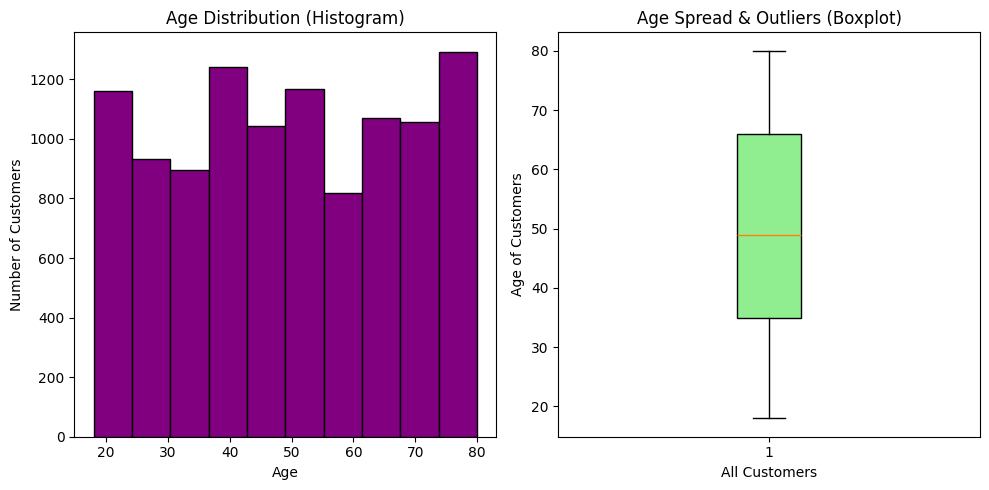

In [47]:
fig, ax = plt.subplots(1,2,figsize = (10,5))
ax[0].hist(US_Customer_Insights_Dataset['Age'],color = 'Purple', edgecolor = 'black')
ax[0].set_title('Age Distribution (Histogram)')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Number of Customers')
ax[1].boxplot(US_Customer_Insights_Dataset['Age'], patch_artist=True,boxprops=dict(facecolor='lightgreen'))
ax[1].set_xlabel('All Customers')
ax[1].set_ylabel('Age of Customers')
ax[1].set_title('Age Spread & Outliers (Boxplot)')
plt.tight_layout()
plt.show()

### Plot histograms and boxplots for MonthlySpend

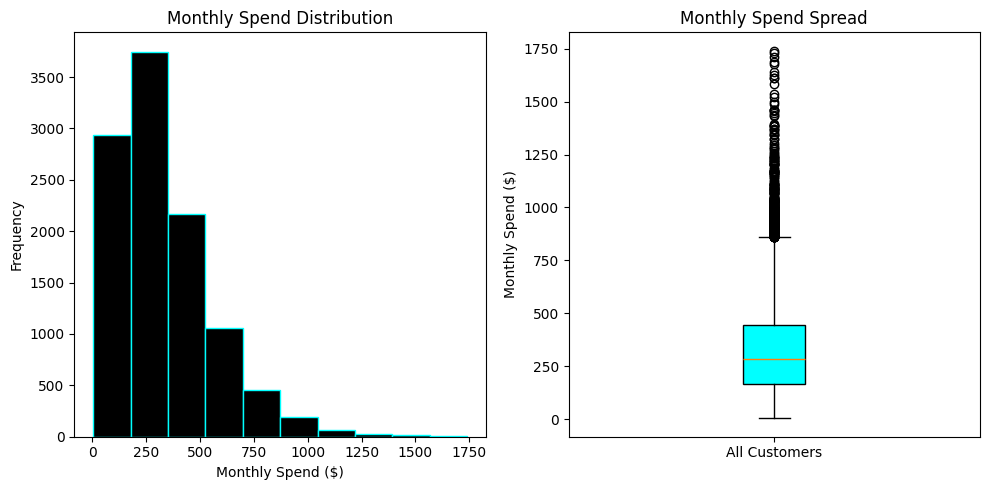

In [48]:
fig, ax = plt.subplots(1,2,figsize = (10,5))
ax[0].hist(US_Customer_Insights_Dataset['MonthlySpend'],color = 'Black', edgecolor = 'cyan')
ax[0].set_title('Monthly Spend Distribution')
ax[0].set_xlabel('Monthly Spend ($)')
ax[0].set_ylabel('Frequency')
ax[1].boxplot(US_Customer_Insights_Dataset['MonthlySpend'],vert=True, patch_artist=True,boxprops=dict(facecolor='Cyan'))
ax[1].set_title('Monthly Spend Spread')
ax[1].set_xticklabels(['All Customers'])
ax[1].set_ylabel('Monthly Spend ($)')
plt.tight_layout()
plt.show()

# Create a bar chart for Gender, Education, State

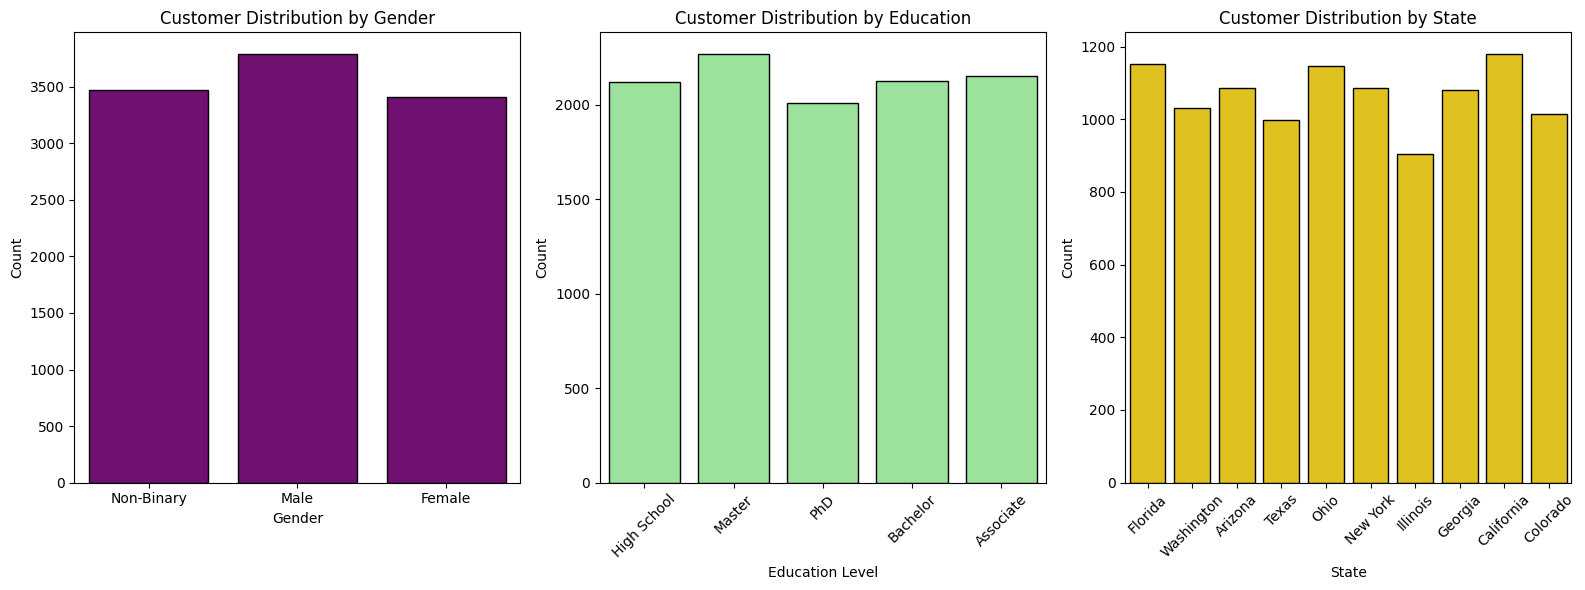

In [49]:
fig, ax = plt.subplots(1, 3, figsize=(16, 6))

sns.countplot(
    data=US_Customer_Insights_Dataset, 
    x='Gender', 
    color='purple', 
    edgecolor='black', 
    ax=ax[0]
)
ax[0].set_title('Customer Distribution by Gender')
ax[0].set_xlabel('Gender')
ax[0].set_ylabel('Count')

sns.countplot(
    data=US_Customer_Insights_Dataset, 
    x='Education', 
    color='lightgreen', 
    edgecolor='black', 
    ax=ax[1]
)
ax[1].set_title('Customer Distribution by Education')
ax[1].set_xlabel('Education Level')
ax[1].set_ylabel('Count')
ax[1].tick_params(axis='x', rotation=45)

sns.countplot(
    data=US_Customer_Insights_Dataset,
    x='State',
    color='Gold',
    edgecolor='black',
    ax=ax[2]
)
ax[2].set_title('Customer Distribution by State')
ax[2].set_xlabel('State')
ax[2].set_ylabel('Count')
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Scatterplot: Age vs MonthlySpend

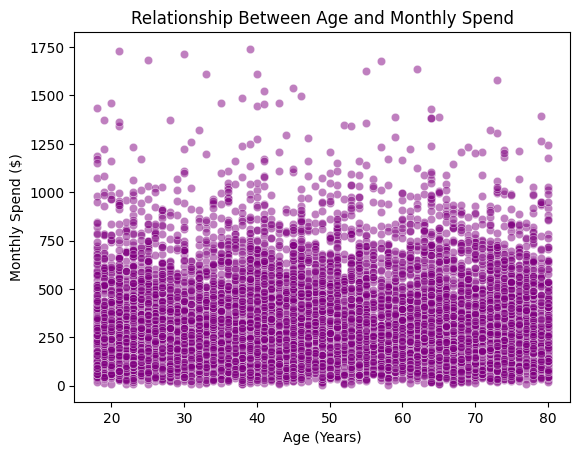

In [50]:
sns.scatterplot(
    x=US_Customer_Insights_Dataset['Age'],
    y=US_Customer_Insights_Dataset['MonthlySpend'],
    color = 'Purple',
    alpha=0.5,
)

plt.title('Relationship Between Age and Monthly Spend')
plt.xlabel('Age (Years)')
plt.ylabel('Monthly Spend ($)')

plt.show()

### KDE: Spending behavior by education level or marital status

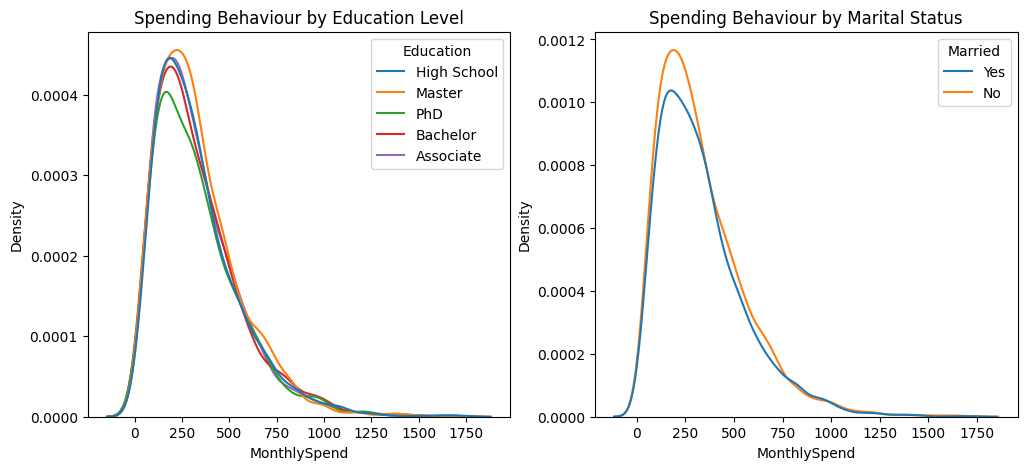

In [51]:
fig, ax = plt.subplots(1,2, figsize = (12,5))
sns.kdeplot(x = US_Customer_Insights_Dataset['MonthlySpend'], hue = US_Customer_Insights_Dataset['Education'],ax = ax[0])
ax[0].set_title('Spending Behaviour by Education Level')
sns.kdeplot(x = US_Customer_Insights_Dataset['MonthlySpend'], hue = US_Customer_Insights_Dataset['Married'],ax = ax[1])
ax[1].set_title('Spending Behaviour by Marital Status')
plt.show()

# Step 4: Bivariate Analysis

**Business Purpose: Check how customer attributes relate to one another.**

### Correlation matrix (numeric variables)

In [52]:
numeric_corr_matrix = US_Customer_Insights_Dataset.corr(numeric_only=True)

styled_matrix = numeric_corr_matrix.style.background_gradient(
    cmap="coolwarm", vmin=-1, vmax=1
).format(precision=2)

styled_matrix

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
Age,1.00,-0.02,-0.01,-0.00
NumPets,-0.02,1.00,0.02,-0.06
MonthlySpend,-0.01,0.02,1.00,0.01
DaysSinceLastInteraction,-0.00,-0.06,0.01,1.00


### Crosstab of Gender vs Married

In [53]:
gender_married_xtab = pd.crosstab(
    index=US_Customer_Insights_Dataset["Gender"],
    columns=US_Customer_Insights_Dataset["Married"],
    margins=True,
    margins_name="Total",
)

print(gender_married_xtab)

Married       No   Yes  Total
Gender                       
Female      1797  1616   3413
Male        1892  1899   3791
Non-Binary  1894  1577   3471
Total       5583  5092  10675


### Grouped stats: average MonthlySpend by State, Education, Gender

In [54]:
pivot_spend = US_Customer_Insights_Dataset.pivot_table(
    values="MonthlySpend",
    index="State",
    columns=["Education", "Gender"],
    aggfunc="mean",
).round(2)
 
styled_pivot = pivot_spend.style.background_gradient(
    cmap="YlGnBu", axis=1
).format("${:,.2f}")

styled_pivot

### Step 5: Formulate Hypotheses

**Business Purpose: Turn business questions into statistical tests.**

**1. Do males and females spend differently?**
* **Statistical Test:** Independent t-test
* **Null Hypothesis H0:** The mean `MonthlySpend` for males is equal to the mean `MonthlySpend` for females. μ(male) = μ(female)
* **Alternative Hypothesis H1:** The mean `MonthlySpend` for males is significantly different from females. μ(male)≠(female)

**2. Does education level impact average monthly spend?**
* **Statistical Test:** One-Way ANOVA (Analysis of Variance)
* **Null Hypothesis H0):** The mean `MonthlySpend` is the same across all education levels. (μ(High School) = μ(Bachelors) = μ(Masters)= ....)
* **Alternative Hypothesis H1:** At least one education level group has a significantly different mean `MonthlySpend` compared to the others.

**3. Are older people less active?**
* **Statistical Test:** Correlation Test (Age vs Days since last interaction)
* **Null Hypothesis H_0:** There is no relationship between `Age` and `DaysSinceLastInteraction`. (r = 0)
* **Alternative Hypothesis H1:** There is a significant positive relationship between `Age` and `DaysSinceLastInteraction` r > 0. 

**4. Does state-wise spend vary significantly?**
* **Statistical Test:** One-Way ANOVA
* **Null Hypothesis H_0:** The mean `MonthlySpend` is identical across all states. (μ(State A) = μ(State B) = ......)
* **Alternative Hypothesis H1:** At least one state has a significantly different mean `MonthlySpend` compared to the others.

# Step 6: Run Hypothesis Tests

**Business Purpose: Validate or reject your assumptions with confidence.**

**● Define null and alternate hypotheses**

**● Define null and alternate hypotheses**

**● Choose test based on data types**

**● Check assumptions: normality, independence, homogeneity of variance**

**● Interpret p-values and confidence intervals**

**Do males and females spend differently?**

In [55]:
male = US_Customer_Insights_Dataset[US_Customer_Insights_Dataset['Gender'] == 'Male']['MonthlySpend']
female = US_Customer_Insights_Dataset[US_Customer_Insights_Dataset['Gender'] == 'Female']['MonthlySpend']

result = (ttest_ind(male,female))
p_value = result.pvalue
print(f'p value {p_value}')

if p_value < 0.05:
    print("H0 Rejected and H1 Accepted")
else:
    print("H0 Accepted")

p value 0.7344892727022861
H0 Accepted


* **Hypothesis Decision:** Fail to reject the Null Hypothesis H0.
* **Statistical Finding:** The test confirms that the Null Hypothesis H0 stands. There is no statistically significant difference between the mean `MonthlySpend` of male and female customers (p > 0.05).
* **Business Insight:** Gender does not act as a driving factor for customer purchasing volume in this dataset. Marketing campaigns and budget allocations targeting spend habits should treat male and female segments equally, as their spending distributions are statistically identical.

**Does education level impact average monthlyspend?**

In [56]:
high_school = US_Customer_Insights_Dataset[US_Customer_Insights_Dataset['Education'] == 'High School']['MonthlySpend']
master = US_Customer_Insights_Dataset[US_Customer_Insights_Dataset['Education'] == 'Master']['MonthlySpend']
phd = US_Customer_Insights_Dataset[US_Customer_Insights_Dataset['Education'] == 'PhD']['MonthlySpend']
bachelor = US_Customer_Insights_Dataset[US_Customer_Insights_Dataset['Education'] == 'Bachelor']['MonthlySpend']
associate = US_Customer_Insights_Dataset[US_Customer_Insights_Dataset['Education'] == 'Associate']['MonthlySpend']

f_stat, p_value = f_oneway(high_school, master, phd, bachelor, associate)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("H0 Rejected and H1 Accepted")
else:
    print("Fail to reject H0 (The Null Hypothesis Stands)")

F-Statistic: 0.2288
P-value: 0.9223594677600564
Fail to reject H0 (The Null Hypothesis Stands)


* **Hypothesis Decision:** Fail to reject the Null Hypothesis H0.
* **Statistical Finding:** The One-Way ANOVA test confirms that the Null Hypothesis H0 stands (F(4) = 0.2288, p = 0.9224). There is no statistically significant difference in the mean `MonthlySpend` across the different education levels (High School, Associate, Bachelor, Master, PhD).
* **Business Insight:** A customer's formal level of education does not drive or predict their monthly purchasing volume in this market segment. The exceptionally high p-value (92.24%) emphasizes that any minor variance observed between the groups is entirely due to random sampling fluctuations. 
* **Strategic Recommendation:** Marketing strategies, product pricing tiers, and promotional campaigns do not need to be segmented or tailored based on educational degrees, as spending behavior remains uniform across all educational backgrounds.

**Are older people less active?**

In [57]:
corr = US_Customer_Insights_Dataset[['Age','DaysSinceLastInteraction']].corr()
corr

,Age,DaysSinceLastInteraction
Age,1.00000,-0.00397
DaysSinceLastInteraction,-0.00397,1.00000


* **Hypothesis Decision:** Fail to reject the Null Hypothesis H0.
* **Statistical Finding:** The Pearson correlation test indicates that the Null Hypothesis H0 stands. The correlation coefficient between `Age` and `DaysSinceLastInteraction` is practically zero (r = -0.0040). There is no linear relationship between a customer's age and their interaction patterns.
* **Business Insight:** Older individuals are not less active in this customer ecosystem. Customer engagement—measured by the number of days since their last interaction—remains completely uniform across all generations, meaning age is a poor metric for predicting user inactivity or platform churn.
* **Strategic Recommendation:** Do not build re-engagement campaigns or retention flows around customer age brackets. Instead, look into other potential churn indicators (such as historical spending volume or customer support tickets) to address drop-offs in platform activity

**Does state-wise spend vary significantly?**

In [58]:
state_groups = [
    group["MonthlySpend"].values
    for name, group in US_Customer_Insights_Dataset.groupby("State")
]

f_stat, p_value = f_oneway(*state_groups)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("H0 Rejected and H1 Accepted")
else:
    print("Fail to reject H0 (The Null Hypothesis Stands)")

F-Statistic: 1.1178
P-value: 0.34571886479464203
Fail to reject H0 (The Null Hypothesis Stands)


* **Hypothesis Decision:** Fail to reject the Null Hypothesis (H0).
* **Statistical Finding:** The One-Way ANOVA test confirms that the Null Hypothesis (H0) stands (F = 1.1178, p = 0.3457). There is no statistically significant difference in the mean `MonthlySpend` across the different US states in the dataset.
* **Business Insight:** Customer value and purchasing power are regionally uniform. A customer's geographic location (state) does not drive or predict their monthly spending behavior. The p-value (34.57%) is well above our significance threshold (alpha = 0.05), proving that any slight variations in average spending between states are entirely due to random sampling fluctuations.
* **Strategic Recommendation:** Regional or state-level custom pricing tiers and specialized regional marketing distributions are unnecessary for driving raw sales volume. Marketing assets can safely remain generalized at a national scale, saving operational overhead and design resources.

# Step 7: Present Business Insights

**1.Majority of spending is between 0- 750$ as can be seen in th box plot. Thus there can be an increase in products within that cost range**

**2.There is a small difference beyween the monthly spending of married and unmarried people. Where unmarried people tend to spend more than the married. Thus more promotional messages to unmarried people can increase sales**

**3.Our independent t-test yielded a p-value of 0.7345, meaning there is no statistical variance in spending patterns between male and female cohorts. Thus we can avoid costly gender-segmented advertising or separate product lines. Marketing assets and promotional campaigns should stay broad, inclusive, and standardized across all genders.**

**4.The state-by-state One-Way ANOVA test showed a p-value of 0.3457, meaning geographical location does not dictate spending habits. Consolidate localized marketing budgets. Instead of managing ten separate localized state campaigns, launch a singular, high-budget national campaign to reduce administrative workloads and design costs while maximizing reach.**

**5.The correlation between customer age and days since last interaction was practically non-existent (r = -0.0040). Disregard age boundaries when deploying automated win-back emails or churn-prevention alerts. Treat a drop-off in customer interaction identically whether the user is 22 or 65, utilizing identical timing triggers for all churn-prevention automation.**